### Finding Roots with Newton-Raphson

In [3]:
from math import factorial, sin, cos, e
import numpy as np
import matplotlib.pyplot as plt

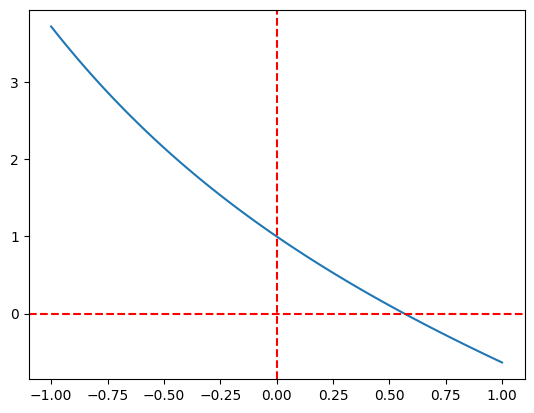

In [3]:
#function we will find roots for

epsilon=.0001 #required accuracy

def h(x):
    return e**(-x) -x

#plot this function
xs = np.linspace(-1, 1, 100)
ys = [h(x0) for x0 in xs]
plt.plot(xs,ys)
plt.axvline(x=0,color='r', linestyle='--')
plt.axhline(y=0,color='r', linestyle='--')
plt.show()

In [4]:
#based on your plot, pick an initial x_guess for the root location

x_guess = 0.6

#evaluate the function at the location of our guess
y0 = h(x_guess)
print('value of y at initial guess= ',y0)

value of y at initial guess=  -0.05118836390597348


In [5]:
#define a function to evaluate derivatives of h(x)

def deriv_h(x):
    return -1*e**(-x) -1

#first make sure the derivative of h(x) is not zero at our current guess
print('current derivative= ',deriv_h(x_guess))

current derivative=  -1.5488116360940265


In [6]:
#define a function to evaluate the Newton-Raphson formula to update your root guess

def nr_update(x1):
    x2 = x1 - (h(x1)/deriv_h(x1))
    return x2

In [7]:
#evaluate the new x_guess
x_guess_new = nr_update(x_guess)
print('xi+1= ', x_guess_new, 'h(xi+1) = ',h(x_guess_new))

#did our estimate of the root improve in a single iteration? 

xi+1=  0.5669499100387273 h(xi+1) =  0.0003030653561180152


In [8]:
#define function to evaluate relative error
def error_size(x1,x2):
    return (x2-x1)/x1

err = error_size(x_guess, x_guess_new)

print('relative error: ', err)


# is our error within the required accuracy?

if(abs(err) < epsilon):
    print('done! achieved required accuracy')
else:
    print('accuracy not achieved yet')

relative error:  -0.0550834832687878
accuracy not achieved yet


In your homework assignment, you will need to write a single function that performs all of these steps.
Try to think: at what point would I stop if I were solving this analytically? Which Python function can achieve this?

### Linear Systems - LU Decomposition

In this section, we will start after Crout's method, assuming that $A = LU$.
The objective of this method is to find the vector $x$ that satisfies: $Ax = c$.

We will focus only on finding the intermediate vector $y_i$. Once you understand the underlying logic, you will be able to apply it to the more "complex" cases: finding $x_i$—our final goal—as you have learned in class.

In [7]:
import numpy as np

# The Original Matrix A
A = np.array([[1, 3, 2],
              [2, 4, 3],
              [3, 4, 7]], dtype=float)

# Remember that Ax = c
c = np.array([15, 22, 39], dtype=float)

The following matrices are the EXPECTED RESULTS of the Crout calculation!
In your homework, you will generate these using your loops and formulas.

In [5]:
# Expected Matrix U (Upper)
# Note how the first row is identical to A, but others change due to the subtraction of sums.
U_expected = np.array([[1.0, 3.0, 2.0],
                       [0.0, -2.0, -1.0],
                       [0.0, 0.0, 3.5]])

# Expected Matrix L (Lower)
# Note how the diagonal is exactly 1.0 (Crout's convention).
L_expected = np.array([[1.0, 0.0, 0.0],
                       [2.0, 1.0, 0.0],
                       [3.0, 2.5, 1.0]])

# Printing the results
print("--- Original Matrix A ---")
print(A)

print("\n--- Calculated Matrix U (Upper) ---")
print(U_expected)

print("\n--- Calculated Matrix L (Lower) ---")
print(L_expected)

# Verification
print("\nVerification (L * U):")
print(np.dot(L_expected, U_expected))

--- Original Matrix A ---
[[1. 3. 2.]
 [2. 4. 3.]
 [3. 4. 7.]]

--- Calculated Matrix U (Upper) ---
[[ 1.   3.   2. ]
 [ 0.  -2.  -1. ]
 [ 0.   0.   3.5]]

--- Calculated Matrix L (Lower) ---
[[1.  0.  0. ]
 [2.  1.  0. ]
 [3.  2.5 1. ]]

Verification (L * U):
[[1. 3. 2.]
 [2. 4. 3.]
 [3. 4. 7.]]


In [9]:
# Assuming L and the constant vector c are already defined
n = L_expected.shape[0]
y = np.zeros(n)

# define a function to evaluate the forward substitution for a single y_i
def calculate_yi(L, c, y, i):
    # 1. Calculate the sum of known values: 
    # Multiply the coefficients in L by the y values we already found
    ____
    # 2. Subtract the sum from the constant c[i] to isolate y[i]
    ____
    return _

# We move "Forward" from the first row to the last
for _ in range(_):

print("Intermediate Vector y:")
print(y)

Intermediate Vector y:
[15. -8. 14.]


In your homework assignment, apply what we learned today about finding $y$ to solve for $x$. Remember that we are now working with the equation $Ux = y$, which requires back substitution. Think about how you can implement a loop that runs backwards instead of forwards.